In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import os
import torch
import numpy as np
import copy
import warnings
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict

warnings.filterwarnings("ignore", category=UserWarning)

# 导入解耦后的模块（使用项目根目录包路径）
from configs.default_config import Config
from envs.env_multi import MultiEnergyStorageEnv as EnergyStorageEnv
from common.replay_buffer import ReplayBuffer
from madrl.maddpg import MADDPG
from madrl.matd3 import MATD3

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# 初始化配置
args = Config()
# 增加一个实验用的权重参数
args.w_pv_rolling = 1.0 

def my_custom_reward(agent_id: int, action: float, physics: dict, price: float) -> float:
    """
    在这里设计你的奖励函数！
    """
    actual_power = physics['ess_power'][agent_id]
    
    # 1. 经济效益
    economic_reward = -actual_power * price
    
    # 2. SOC 越限惩罚 (从环境传入)
    soc_penalty = physics['soc_penalties'][agent_id]
    
    # 3. 削峰填谷协同惩罚
    peak_penalty = 0
    if args.w_pv_rolling > 0 and physics['net_load_std'] > 0:
        peak_penalty = -args.w_pv_rolling * physics['net_load_std'] / args.num_agents
        
    return economic_reward + soc_penalty + peak_penalty

In [3]:
class Runner:
    def __init__(self, args, env_name, number, seed):
        self.args = args
        self.env_name = env_name
        
        # 实例化环境，注入 reward_fn
        self.env = EnergyStorageEnv(args, reward_fn=my_custom_reward, mode='train')
        self.env_evaluate = EnergyStorageEnv(args, reward_fn=my_custom_reward, mode='test')
        
        # 补齐你 Agent 需要的额外参数
        self.args.N = self.env.n
        self.args.obs_dim_n = [self.env.observation_space[i].shape[0] for i in range(self.args.N)]
        self.args.action_dim_n = [self.env.action_space[i].shape[0] for i in range(self.args.N)]
        
        np.random.seed(seed)
        torch.manual_seed(seed)

        if self.args.algorithm == "MADDPG":
            self.agent_n = [MADDPG(args, i) for i in range(args.N)]
        elif self.args.algorithm == "MATD3":
            self.agent_n = [MATD3(args, i) for i in range(args.N)]

        self.replay_buffer = ReplayBuffer(self.args)
        self.writer = SummaryWriter(log_dir=f'runs/{self.args.algorithm}_{env_name}_{number}_seed_{seed}')
        
        self.history = []
        self.episode_rewards = []
        self.total_steps = 0
        self.noise_std = self.args.noise_std_init

    def save_model(self, model_dir, episode):
        # 在模型目录中为特定算法创建一个子目录
        algo_model_dir = os.path.join(model_dir, self.args.algorithm)
        if not os.path.exists(algo_model_dir):
            os.makedirs(algo_model_dir)
        for agent in self.agent_n:
            # 调用时不传递 agent_id，因为它已在 agent 内部定义
            agent.save_model(algo_model_dir, episode)
        print(f"Models saved to {algo_model_dir}")

    def load_model(self, model_dir, episode):
        # 从特定算法的子目录加载模型
        algo_model_dir = os.path.join(model_dir, self.args.algorithm)
        for agent in self.agent_n:
            agent.load_model(algo_model_dir, episode)
        print(f"Models loaded from {algo_model_dir}")

    def run(self):
        episode_num = 0
        target_episodes = getattr(self.args, 'train_episodes', int(self.args.max_train_steps / self.args.episode_limit))

        pbar = tqdm(total=target_episodes, desc='Training', unit='ep')
        try:
            while episode_num < target_episodes:
                obs_n = self.env.reset()
                episode_reward = 0
                episode_actions_history = [[] for _ in range(self.args.N)]
                episode_soc_history = [[] for _ in range(self.args.N)]
                episode_price_history = []
                episode_original_load_history = []
                episode_net_load_history = []
                episode_original_load_cost_history = []
                episode_ess_profit_history = []
                episode_soc_penalty_history = []
                episode_peak_valley_penalty_history = []
                episode_cost_with_ess_history = []
                for i in range(self.args.N):
                    episode_soc_history[i].append(self.env.battery_soc[i])

                for _ in range(self.args.episode_limit):
                    a_n = [agent.choose_action(obs, noise_std=self.noise_std) for agent, obs in zip(self.agent_n, obs_n)]
                    obs_next_n, r_n, done_n, info = self.env.step(a_n)
                    episode_reward += sum(r_n)

                    episode_price_history.append(info['price'])
                    episode_original_load_history.append(info['original_total_load'])
                    episode_net_load_history.append(info['net_total_load'])
                    episode_original_load_cost_history.append(info['original_load_cost'])
                    episode_ess_profit_history.append(info['ess_profit'])
                    episode_soc_penalty_history.append(info['soc_penalty'])
                    episode_peak_valley_penalty_history.append(info['peak_valley_penalty'])
                    episode_cost_with_ess_history.append(info['cost_with_ess'])
                    for i in range(self.args.N):
                        episode_actions_history[i].append(info['ess_power'][i])
                        episode_soc_history[i].append(info['soc'][i])

                    self.replay_buffer.store_transition(obs_n, a_n, r_n, obs_next_n, done_n)
                    obs_n = obs_next_n
                    self.total_steps += 1

                    if self.args.use_noise_decay:
                        self.noise_std = self.noise_std - self.args.noise_std_decay if self.noise_std - self.args.noise_std_decay > self.args.noise_std_min else self.args.noise_std_min

                    if self.replay_buffer.current_size > self.args.batch_size:
                        for agent_id in range(self.args.N):
                            self.agent_n[agent_id].train(self.replay_buffer, self.agent_n)

                    if all(done_n):
                        break

                episode_num += 1
                pbar.update(1)

                self.history.append({
                    'actions': episode_actions_history,
                    'soc': episode_soc_history,
                    'price': episode_price_history,
                    'original_load': episode_original_load_history,
                    'net_load': episode_net_load_history,
                    'original_load_cost': episode_original_load_cost_history,
                    'ess_profit': episode_ess_profit_history,
                    'soc_penalty': episode_soc_penalty_history,
                    'peak_valley_penalty': episode_peak_valley_penalty_history,
                    'cost_with_ess': episode_cost_with_ess_history
                })
                self.episode_rewards.append(episode_reward)
                avg_reward = np.mean(self.episode_rewards[-50:]) if len(self.episode_rewards) >= 50 else np.mean(self.episode_rewards)

                pbar.set_postfix({'avg_reward': f'{avg_reward:.2f}', 'steps': self.total_steps})

                if episode_num % 20 == 0 or episode_num == 1 or episode_num == target_episodes:
                    print(f"Episode: {episode_num}/{target_episodes}, Total Steps: {self.total_steps}, Reward: {episode_reward:.2f}, Avg Reward: {avg_reward:.2f}")

                self.writer.add_scalar('train_episode_rewards_{}'.format(self.env_name), episode_reward, global_step=self.total_steps)
                self.writer.add_scalar('avg_episode_rewards_{}'.format(self.env_name), avg_reward, global_step=self.total_steps)
        finally:
            pbar.close()
            self.env.close()
            self.env_evaluate.close()

        return episode_num

In [ ]:
# 运行训练
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
runner = Runner(args, env_name="EnergyStorage", number=1, seed=0)
trained_episodes = runner.run()

# 保存模型
model_save_dir = "./saved_models"
final_episode = getattr(args, 'train_episodes', trained_episodes)
runner.save_model(model_save_dir, episode=final_episode)

------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------


Training:   0%|          | 0/300 [00:00<?, ?ep/s]

Episode: 1/300, Total Steps: 96, Reward: -349.90, Avg Reward: -349.90


--- Plotting Training Process Analysis ---


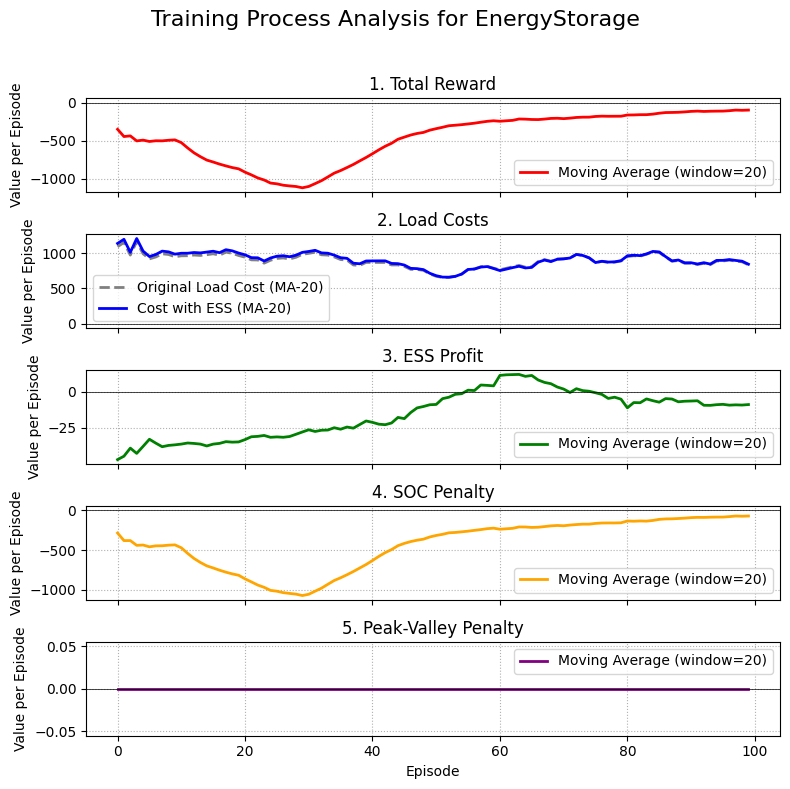

In [ ]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import pandas as pd
import numpy as np

# --- 1. Plot Training Process Analysis (5 separate subplots) ---
print("--- Plotting Training Process Analysis ---")

# --- Data Aggregation ---
# Extract the sum of each metric per episode from history
ep_original_load_cost = [np.sum(ep_data['original_load_cost']) for ep_data in runner.history]
ep_ess_profit = [np.sum(ep_data['ess_profit']) for ep_data in runner.history]
ep_soc_penalty = [np.sum(ep_data['soc_penalty']) for ep_data in runner.history]
ep_peak_valley_penalty = [np.sum(ep_data['peak_valley_penalty']) for ep_data in runner.history]
ep_cost_with_ess = [np.sum(ep_data['cost_with_ess']) for ep_data in runner.history]

# --- Plotting ---
# Use a moving average to smooth the curves
window_size = 20

# --- Create a figure with 5 vertical subplots, sharing the X-axis ---
fig, axs = plt.subplots(5, 1, figsize=(8, 8), sharex=True)
fig.suptitle(f'Training Process Analysis for {runner.env_name}', fontsize=16)

# --- Subplot 1: Total Reward ---
ax = axs[0]
data_ma = pd.Series(runner.episode_rewards).rolling(window=window_size, min_periods=1).mean()
ax.plot(data_ma, color='red', linewidth=2, label=f'Moving Average (window={window_size})')
ax.set_title("1. Total Reward")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

# --- Subplot 2: Load Costs (Combined) ---
ax = axs[1]
# Original Load Cost
original_cost_ma = pd.Series(ep_original_load_cost).rolling(window=window_size, min_periods=1).mean()
ax.plot(original_cost_ma, color='gray', linestyle='--', linewidth=2, label=f'Original Load Cost (MA-{window_size})')
# Cost with ESS
cost_with_ess_ma = pd.Series(ep_cost_with_ess).rolling(window=window_size, min_periods=1).mean()
ax.plot(cost_with_ess_ma, color='blue', linewidth=2, label=f'Cost with ESS (MA-{window_size})')
ax.set_title("2. Load Costs")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

# --- Subplot 3: ESS Profit ---
ax = axs[2]
data_ma = pd.Series(ep_ess_profit).rolling(window=window_size, min_periods=1).mean()
ax.plot(data_ma, color='green', linewidth=2, label=f'Moving Average (window={window_size})')
ax.set_title("3. ESS Profit")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

# --- Subplot 4: SOC Penalty ---
ax = axs[3]
data_ma = pd.Series(ep_soc_penalty).rolling(window=window_size, min_periods=1).mean()
ax.plot(data_ma, color='orange', linewidth=2, label=f'Moving Average (window={window_size})')
ax.set_title("4. SOC Penalty")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

# --- Subplot 5: Peak-Valley Penalty ---
ax = axs[4]
data_ma = pd.Series(ep_peak_valley_penalty).rolling(window=window_size, min_periods=1).mean()
ax.plot(data_ma, color='purple', linewidth=2, label=f'Moving Average (window={window_size})')
ax.set_title("5. Peak-Valley Penalty")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')


axs[-1].set_xlabel('Episode')
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"training_analysis_subplots_{runner.env_name}.png")
plt.show()


--- Plotting Detailed Results ---
Episodes to plot (1-based): [1, 34, 67, 100]


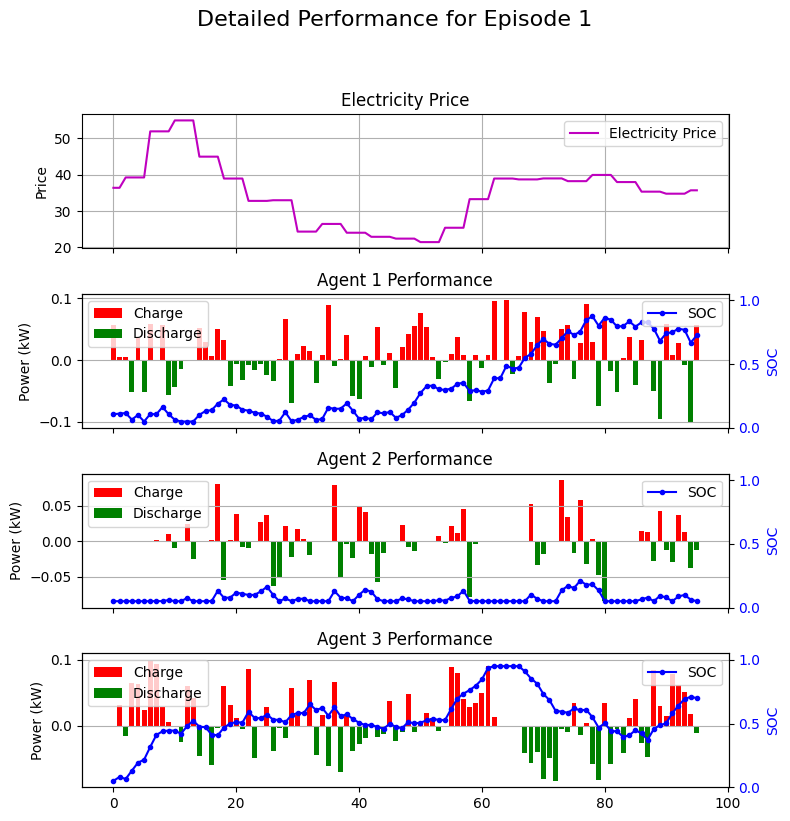

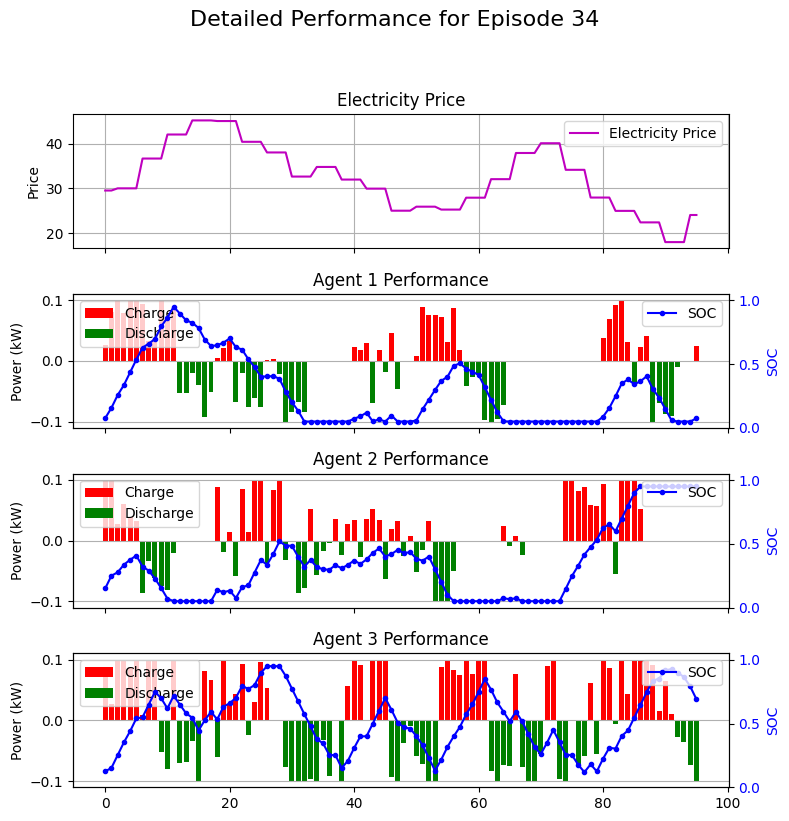

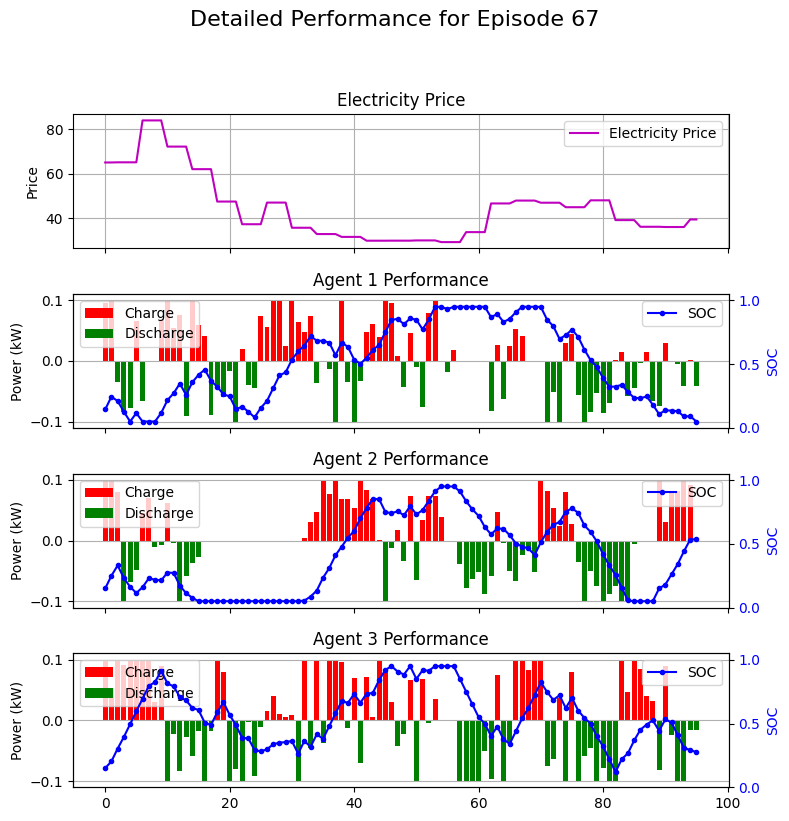

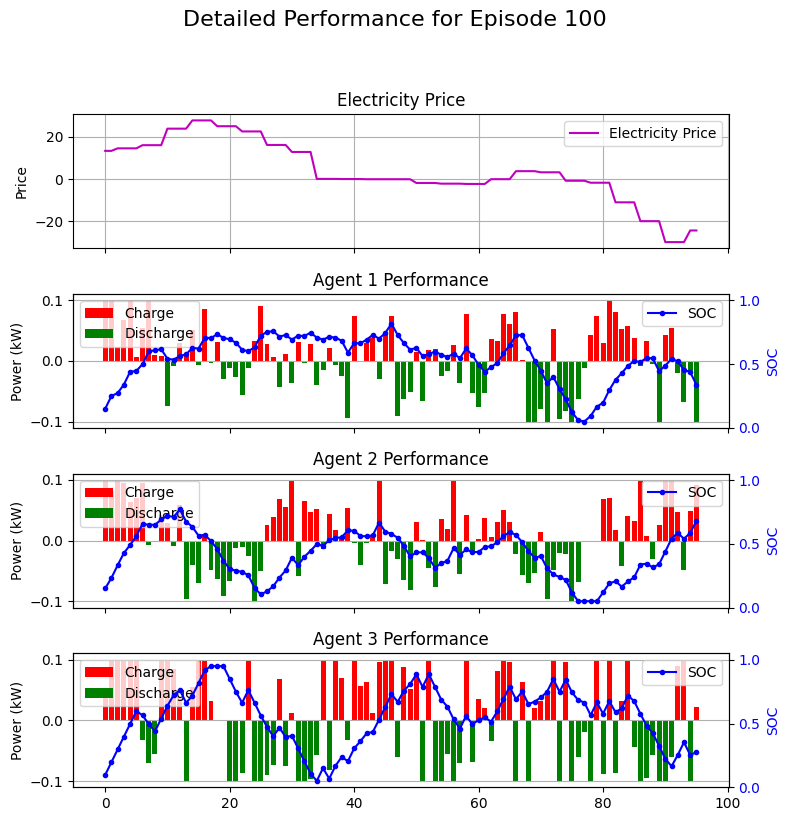

In [ ]:
# --- 2. 可视化指定多个训练回合的数据 ---
print("\n--- Plotting Detailed Results ---")

total_episodes = len(runner.history)
if total_episodes == 0:
    print("No training history found. Please run training first.")
else:
    episodes_to_plot = sorted(set([0, total_episodes // 3, (2 * total_episodes) // 3, total_episodes - 1]))
    print(f"Episodes to plot (1-based): {[e + 1 for e in episodes_to_plot]}")

    for episode_idx in episodes_to_plot:
        if episode_idx >= len(runner.history) or episode_idx < 0:
            print(f"Warning: Episode {episode_idx + 1} not found. Skipping. (Total episodes trained: {len(runner.history)})")
            continue

        episode_data = runner.history[episode_idx]
        price_history = episode_data['price']
        actions_history = episode_data['actions']
        soc_history = episode_data['soc']

        fig, axs = plt.subplots(args.N + 1, 1, figsize=(8, 2 * (args.N + 1)), sharex=True)
        if args.N == 0:
            axs = [axs]

        fig.suptitle(f'Detailed Performance for Episode {episode_idx + 1}', fontsize=16, y=1.02)
        time_steps = np.arange(len(price_history))

        ax_price = axs[0]
        ax_price.plot(time_steps, price_history, 'm-', label='Electricity Price')
        ax_price.set_ylabel('Price')
        ax_price.set_title('Electricity Price')
        ax_price.legend()
        ax_price.grid(True)

        for i in range(args.N):
            ax1 = axs[i + 1]
            charge_power = np.array(actions_history[i])
            ax1.bar(time_steps, np.maximum(0, charge_power), color='r', width=0.8, label='Charge')
            ax1.bar(time_steps, np.minimum(0, charge_power), color='g', width=0.8, label='Discharge')
            ax1.set_ylabel('Power (kW)', color='k')
            ax1.set_title(f'Agent {i+1} Performance')
            ax1.legend(loc='upper left')
            ax1.grid(True, axis='y')

            ax2 = ax1.twinx()
            ax2.plot(time_steps, soc_history[i][1:], 'b-', marker='.', label='SOC')
            ax2.set_ylabel('SOC', color='b')
            ax2.tick_params(axis='y', labelcolor='b')
            ax2.set_ylim(0, 1.05)
            ax2.legend(loc='upper right')

        plt.xlabel('Time Step')
        fig.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

In [ ]:
# smoke test: 环境可实例化并 reset
_env = EnergyStorageEnv(args, reward_fn=my_custom_reward, mode='train')
_obs = _env.reset()
print(f"env_agents={_env.n}, obs_len_agent0={len(_obs[0])}")

env_agents=3, obs_len_agent0=53


In [ ]:
# smoke test: Runner 单步联调（不进行完整训练）
_runner = Runner(args, env_name="EnergyStorage", number=0, seed=0)
_obs_n = _runner.env.reset()
_a_n = [agent.choose_action(obs, noise_std=0.0) for agent, obs in zip(_runner.agent_n, _obs_n)]
_obs_next_n, _r_n, _done_n, _info = _runner.env.step(copy.deepcopy(_a_n))
_runner.replay_buffer.store_transition(_obs_n, _a_n, _r_n, _obs_next_n, _done_n)
print(f"step_ok=True, reward_sum={float(np.sum(_r_n)):.4f}, buffer_size={_runner.replay_buffer.current_size}")

------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
step_ok=True, reward_sum=-10.6250, buffer_size=1
